# Notebook 03: Análisis Exploratorio de Datos (EDA) Sociodemográfico

**Objetivos de este notebook:**
1. Cargar el DataFrame maestro consolidado en el paso anterior.
2. Crear funciones de graficación que incorporen el Factor de Expansión (`fex_c`) automáticamente.
3. Analizar la distribución demográfica poblacional (Sexo, Edad, Estado Civil).
4. Analizar el nivel educativo y características de salud general/mental.
5. Guardar los gráficos generados en la carpeta `outputs/figures/` para incluirlos en el documento de tesis.

**Importante:** En la estadística oficial del DANE, 1 fila no es 1 persona. 1 fila representa a $N$ personas en la población real, donde $N$ es el valor de la columna `fex_c`. Todos los cálculos de este notebook están ponderados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Ignorar advertencias menores de seaborn
warnings.filterwarnings('ignore')

# Configuración de estilo para gráficos (estilo académico/profesional)
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Librerías de análisis y visualización importadas correctamente.")

Librerías de análisis y visualización importadas correctamente.


In [2]:
# Definir rutas
BASE_DIR = Path('..')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
FIGURES_DIR = BASE_DIR / 'outputs' / 'figures'

# Crear carpeta de figuras si no existe
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Cargar el DataFrame Maestro
df = pd.read_parquet(PROCESSED_DIR / 'df_master.parquet')

# Si la columna fex_c está en mayúscula, la pasamos a minúscula por convención de nuestro código
if 'FEX_C' in df.columns:
    df.rename(columns={'FEX_C': 'fex_c'}, inplace=True)

# Limpiar fex_c (asegurar que sea numérico y llenar nulos con 0 por si acaso)
df['fex_c'] = pd.to_numeric(df['fex_c'], errors='coerce').fillna(0)

# Imprimir métricas de control
filas_muestra = len(df)
poblacion_estimada = df['fex_c'].sum()

print(f"Tamaño de la muestra (filas): {filas_muestra:,.0f} personas")
print(f"Población estimada en Colombia (12 a 65 años): {poblacion_estimada:,.0f} personas")

Tamaño de la muestra (filas): 49,756 personas
Población estimada en Colombia (12 a 65 años): 23,747,363 personas


> **Aclaración sobre la Población Estimada:**
> Aunque la población total de Colombia para 2019 rondaba los 50 millones de personas, la suma del factor de expansión de esta encuesta estima una población de **~23.7 millones**. Esto se debe a el *Universo* definido por el DANE: abarca únicamente a personas entre **12 y 65 años**, que viven en **áreas urbanas (cabeceras)** de capitales y municipios con más de 30.000 habitantes, excluyendo áreas rurales, pueblos pequeños y población institucionalizada.
> La franja poblacional de 12 a 65 años representa aproximadamente el 68% de la pirámide poblacional colombiana.


In [4]:
def calcular_frecuencias_ponderadas(df, columna, factor='fex_c'):
    """
    Calcula la frecuencia absoluta y porcentual ponderada de una variable categórica.
    """
    # Agrupar por la categoría y sumar el factor de expansión
    resumen = df.groupby(columna)[factor].sum().reset_index()
    resumen.columns = [columna, 'Poblacion_Estimada']
    
    # Calcular el porcentaje
    total_pob = resumen['Poblacion_Estimada'].sum()
    resumen['Porcentaje (%)'] = (resumen['Poblacion_Estimada'] / total_pob) * 100
    
    # Ordenar de mayor a menor
    resumen = resumen.sort_values('Poblacion_Estimada', ascending=False).reset_index(drop=True)
    
    return resumen

def plot_barras_ponderadas(df_resumen, x_col, y_col='Porcentaje (%)', titulo="", filename=None):
    """
    Genera un gráfico de barras con sus respectivas etiquetas de datos y lo guarda.
    """
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=df_resumen, x=y_col, y=x_col, palette='viridis')
    
    # Agregar etiquetas a las barras
    for p in ax.patches:
        width = p.get_width()
        plt.text(width + 0.5, p.get_y() + p.get_height()/2. + 0.1, 
                 f'{width:.1f}%', ha="center")
        
    plt.title(titulo, pad=15, fontweight='bold')
    plt.xlabel('Porcentaje de la Población (%)')
    plt.ylabel('')
    sns.despine(left=True, bottom=True)
    
    if filename:
        plt.savefig(FIGURES_DIR / f"{filename}.png", dpi=300, bbox_inches='tight')
        print(f"Gráfico guardado en: outputs/figures/{filename}.png")
        
    plt.show()

In [5]:
# Mapear el nivel educativo (Variable d2_05)
dicc_educacion = {
    1: 'Ninguno', 2: 'Preescolar', 3: 'Básica primaria', 
    4: 'Básica secundaria', 5: 'Media', 6: 'Técnica/Tecnológica', 
    7: 'Universitaria', 8: 'Postgrado', 9: 'No sabe / No informa'
}

if 'd2_05' in df.columns:
    df['nivel_educativo'] = df['d2_05'].map(dicc_educacion)

# Mapear estado de salud mental (Variable d_09: ¿Se ha sentido deprimido en los últimos 30 días?)
dicc_depresion = {1: 'Sí', 2: 'No', 9: 'No contesta'}

if 'd_09' in df.columns:
    df['sentimiento_depresion'] = df['d_09'].map(dicc_depresion)

print("Variables adicionales mapeadas correctamente.")

Variables adicionales mapeadas correctamente.


--- DISTRIBUCIÓN POR SEXO ---


,sexo_desc,Poblacion_Estimada,Porcentaje (%)
0,Mujer,"12,288,234",51.75%
1,Hombre,"11,459,129",48.25%



--- DISTRIBUCIÓN POR RANGO DE EDAD ---
Gráfico guardado en: outputs/figures/01_distribucion_rango_edad.png


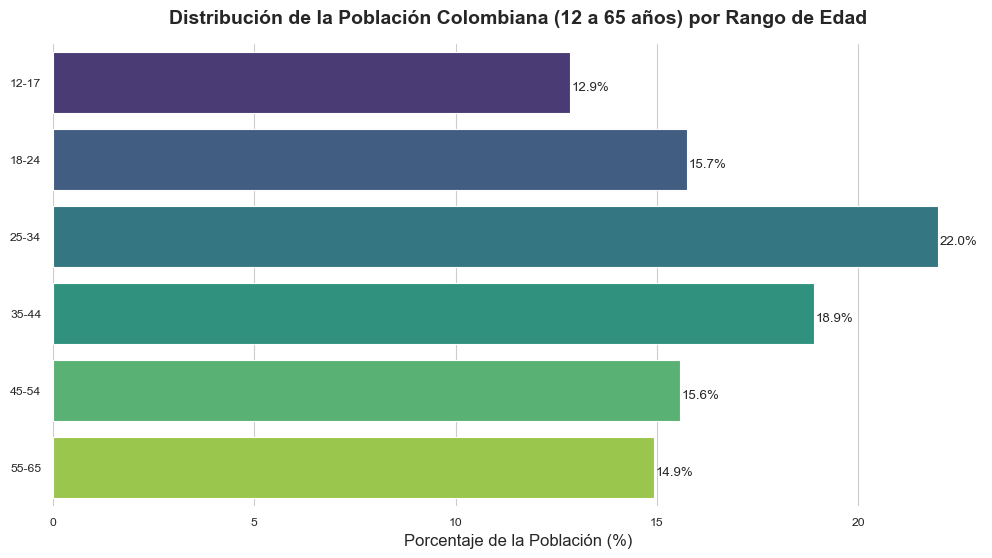

In [6]:
print("--- DISTRIBUCIÓN POR SEXO ---")
df_sexo = calcular_frecuencias_ponderadas(df, 'sexo_desc')
display(df_sexo.style.format({'Poblacion_Estimada': '{:,.0f}', 'Porcentaje (%)': '{:.2f}%'}))

print("\n--- DISTRIBUCIÓN POR RANGO DE EDAD ---")
df_edad = calcular_frecuencias_ponderadas(df, 'rango_edad')

# Graficar Rango de Edad
plot_barras_ponderadas(
    df_edad, 
    x_col='rango_edad', 
    titulo='Distribución de la Población Colombiana (12 a 65 años) por Rango de Edad',
    filename='01_distribucion_rango_edad'
)

Gráfico guardado en: outputs/figures/02_distribucion_nivel_educativo.png


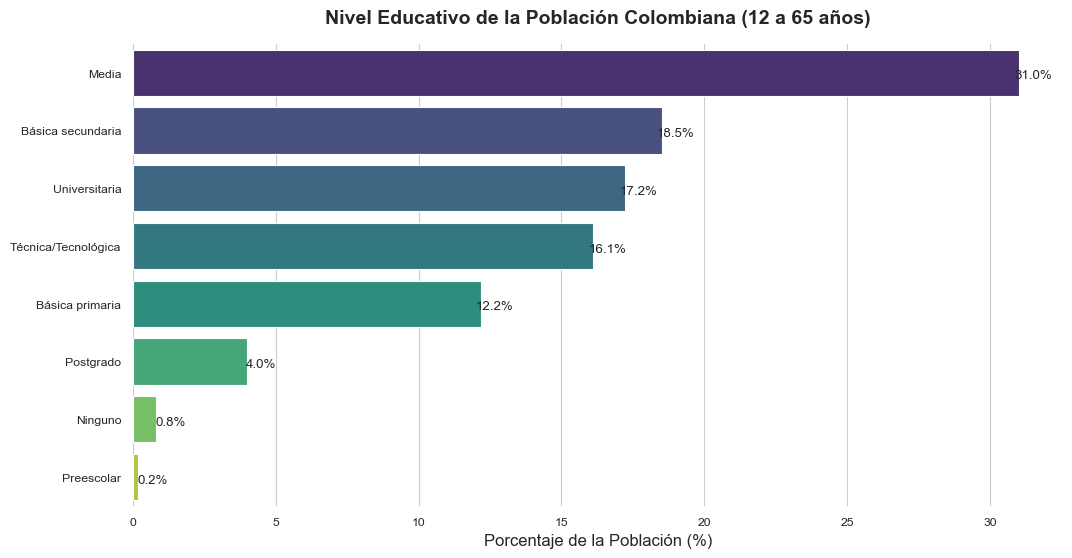

In [7]:
# Calcular frecuencias
df_edu = calcular_frecuencias_ponderadas(df, 'nivel_educativo')

# Filtrar 'No sabe / No informa' para que el gráfico sea más representativo
df_edu_plot = df_edu[df_edu['nivel_educativo'] != 'No sabe / No informa']

plot_barras_ponderadas(
    df_edu_plot, 
    x_col='nivel_educativo', 
    titulo='Nivel Educativo de la Población Colombiana (12 a 65 años)',
    filename='02_distribucion_nivel_educativo'
)

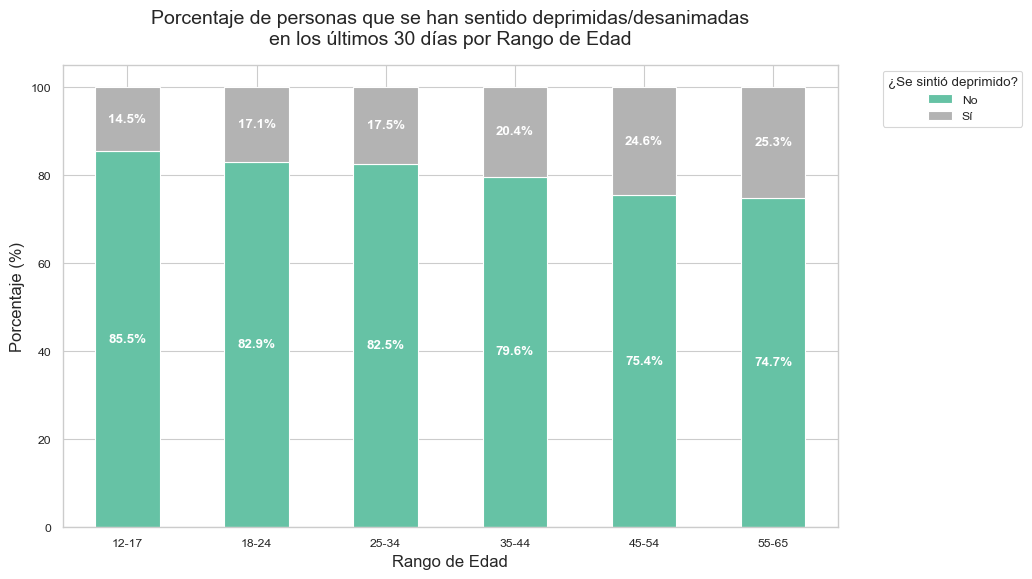

In [ ]:
# Filtrar respuestas válidas
df_salud = df[df['sentimiento_depresion'].isin(['Sí', 'No'])].copy()

# Crear tabla cruzada sumando el factor de expansión
crosstab_depresion = pd.crosstab(
    index=df_salud['rango_edad'], 
    columns=df_salud['sentimiento_depresion'], 
    values=df_salud['fex_c'], 
    aggfunc='sum',
    normalize='index' # Normalizar por filas para obtener porcentajes dentro de cada rango de edad
) * 100

# Graficar
ax = crosstab_depresion.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')

plt.title('Porcentaje de personas que se han sentido deprimidas/desanimadas\nen los últimos 30 días por Rango de Edad', pad=15)
plt.xlabel('Rango de Edad')
plt.ylabel('Porcentaje (%)')
plt.legend(title='¿Se sintió deprimido?', bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    for p in c:  
        height = p.get_height()
        if height > 5: # Solo mostrar texto si el bloque es > 5% para que no se amontone
            ax.text(p.get_x() + p.get_width() / 2., 
                    p.get_y() + height / 2., 
                    f'{height:.1f}%', 
                    ha='center', va='center', color='white', fontweight='bold')

# Rotar las etiquetas del eje X para que se lean mejor
plt.xticks(rotation=0)

plt.savefig(FIGURES_DIR / "03_depresion_por_edad.png", dpi=300, bbox_inches='tight')
plt.show()